# Analyze Eclipse Grid

In [ ]:
# Import Python libraries
!pip install -q -U kaleido==0.2.1 -q -U skimpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 9.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.0/118.0 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 137.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.2/106.2 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 83.8 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: jupyter-client
    Found existing installation: jupyter_client 7.4.9
    Uninstalling jupyter_client-7.4.9:
      Successfully uninstalled jupyter_client-7.4.9
  Attempting uninstall: ipykernel

In [ ]:
import os
from google.colab import drive
from pathlib import Path

# Mount Google Drive (run once per session)
drive.mount("/content/drive")

# Data directory (adjust if you move the notebook)
source = Path("/content/drive/MyDrive/Colab Notebooks/Petroleum Engineering/Data/Norne/INCLUDE/GRID/")
dest = Path("/content/drive/MyDrive/Colab Notebooks/Petroleum Engineering/Output/Norne/")

# Create directory if it does not exist
os.makedirs(dest, exist_ok=True)

print("Source directory:", source)
print("Output directory:", dest)

Mounted at /content/drive
Source directory: /content/drive/MyDrive/Colab Notebooks/Petroleum Engineering/Data/Norne/INCLUDE/GRID
Output directory: /content/drive/MyDrive/Colab Notebooks/Petroleum Engineering/Output/Norne


In [ ]:
from pathlib import Path

# All entries (files + subdirs)
for p in source.iterdir():
    print(p)

# Only files
for p in source.iterdir():
    if p.is_file():
        print(p)

## 1.0 Parse GRDECL and ACTNUM

In [ ]:
import re
from pathlib import Path
import numpy as np

irap_path = Path(source / "IRAP_1005.GRDECL")
actnum_path = Path(source / "ACTNUM_0704.prop")

irap_text = irap_path.read_text(errors="ignore")
act_text = actnum_path.read_text(errors="ignore")

def parse_keyword_block(text, keyword):
    """
    Parse a GRDECL-style block: KEYWORD
      data ...
    /
    Handles N*value syntax.
    """
    m = re.search(rf"\b{keyword}\b\s*(.*?)/", text, flags=re.S)
    if not m:
        return None
    block = m.group(1)
    tokens = re.findall(r"[0-9.Ee+-]+(?:\*[0-9.Ee+-]+)?", block)
    vals = []
    for t in tokens:
        if "*" in t:
            n, v = t.split("*")
            vals.extend([float(v)] * int(float(n)))
        else:
            vals.append(float(t))
    return np.asarray(vals, dtype=float)

# Try to get dimensions; fall back from ZCORN length if needed
m_dim = re.search(r"DIMENS\s*([0-9 ]+)/", irap_text)
if m_dim:
    nx, ny, nz = [int(x) for x in m_dim.group(1).split()[:3]]
else:
    nx = ny = nz = None  # can infer nz from len(ZCORN) if nx,ny known

coord = parse_keyword_block(irap_text, "COORD")   # pillar geometry
zcorn = parse_keyword_block(irap_text, "ZCORN")   # cell corner depths

print("COORD len:", None if coord is None else coord.size)
print("ZCORN len:", None if zcorn is None else zcorn.size)

# Parse ACTNUM from separate prop file (0/1 flags)
act_vals = re.findall(r"\b[01]\b", act_text)
actnum = np.array([int(v) for v in act_vals], dtype=int)
print("ACTNUM len:", actnum.size, "unique:", np.unique(actnum))

COORD len: 31866
ZCORN len: 906752
ACTNUM len: 113348 unique: [0 1]


This gives you COORD, ZCORN, and a flat ACTNUM array with 0/1 flags for inactive/active cells.

## 2.0 Reshape to 3D grids

You need the grid dimensions; if DIMENS is not present, infer from len(zcorn) = 8 * nx * ny * nz once nx, ny are known.

In [ ]:
nx, ny, nz = 46, 112, 22   # from ACTNUM_0704.prop file

if nx is None or ny is None or nz is None:
    raise ValueError("Set nx, ny, nz explicitly once known")

# ZCORN: shape (nz*2, ny*2, nx*2)
zcorn_3d = zcorn.reshape((nz*2, ny*2, nx*2))

# ACTNUM: shape (nz, ny, nx)
expected_actnum_size = nx * ny * nz
if actnum.size != expected_actnum_size:
    print(f"Warning: ACTNUM size {actnum.size} does not match expected size {expected_actnum_size}. Truncating actnum.")
    actnum = actnum[:expected_actnum_size] # Truncate actnum to the expected size

actnum_3d = actnum.reshape((nz, ny, nx))


This gives you regular NumPy arrays you can slice and visualize.

## 3.0 Simple cross‑section plots

### 3.1 Example with matplotlib showing an inline and crossline of ACTNUM:

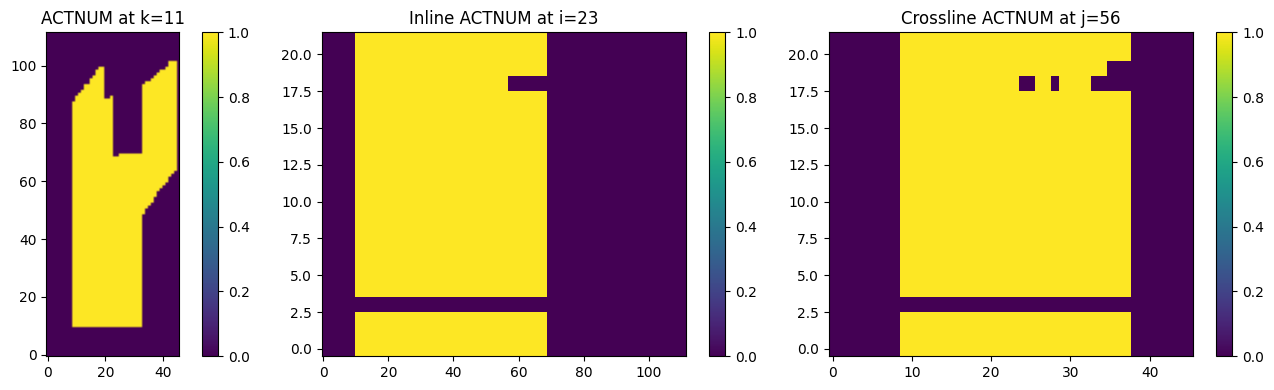

In [ ]:
import matplotlib.pyplot as plt

k_mid = nz // 2     # mid-layer
j_mid = ny // 2     # mid-row
i_mid = nx // 2     # mid-column

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Depth slice (k fixed)
im0 = axes[0].imshow(actnum_3d[k_mid, :, :], origin="lower")
axes[0].set_title(f"ACTNUM at k={k_mid}")
plt.colorbar(im0, ax=axes[0])

# Inline section (i fixed)
im1 = axes[1].imshow(actnum_3d[:, :, i_mid], origin="lower", aspect="auto")
axes[1].set_title(f"Inline ACTNUM at i={i_mid}")
plt.colorbar(im1, ax=axes[1])

# Crossline section (j fixed)
im2 = axes[2].imshow(actnum_3d[:, j_mid, :], origin="lower", aspect="auto")
axes[2].set_title(f"Crossline ACTNUM at j={j_mid}")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

You can replace actnum_3d with any property on the same grid once parsed in the same way.

### 3.2 Example with Plotly showing an inline and crossline of ACTNUM:

In [ ]:
import plotly
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "colab"
import plotly.subplots as sp
import plotly.express as px

k_mid = nz // 2
j_mid = ny // 2
i_mid = nx // 2

fig = sp.make_subplots(
    rows=1, cols=3,
    subplot_titles=(
        f"ACTNUM at k={k_mid}",
        f"Inline ACTNUM at i={i_mid}",
        f"Crossline ACTNUM at j={j_mid}"
    )
)

# Depth slice (k fixed) – shape (ny, nx)
fig.add_trace(
    px.imshow(
        actnum_3d[k_mid, :, :],
        origin="lower",
        color_continuous_scale="Viridis"
    ).data[0],
    row=1, col=1
)

# Inline (i fixed) – shape (nz, ny)
fig.add_trace(
    px.imshow(
        actnum_3d[:, :, i_mid],
        origin="lower",
        color_continuous_scale="Viridis"
    ).data[0],
    row=1, col=2
)

# Crossline (j fixed) – shape (nz, nx)
fig.add_trace(
    px.imshow(
        actnum_3d[:, j_mid, :],
        origin="lower",
        color_continuous_scale="Viridis"
    ).data[0],
    row=1, col=3
)

# Shared colorbar on first trace
for i, tr in enumerate(fig.data):
    tr.colorbar = dict(title="ACTNUM") if i == 0 else None
    tr.showscale = (i == 0)

# Enforce equal x/y scale per subplot
fig.update_xaxes(scaleanchor="y", row=1, col=1)
fig.update_yaxes(constrain="domain", row=1, col=1)

fig.update_xaxes(scaleanchor="y2", row=1, col=2)
fig.update_yaxes(constrain="domain", row=1, col=2)

fig.update_xaxes(scaleanchor="y3", row=1, col=3)
fig.update_yaxes(constrain="domain", row=1, col=3)

fig.update_layout(width=1200, height=400)

# Define title here to be accessible for saving
plot_title = "ACTNUM Plots"

# Ensure dest is a Path object for file operations
dest = Path(dest) # Explicitly convert dest to Path

plotly.offline.plot(fig, filename = str(dest / (plot_title + '.html'))) # Changed plotly.offline.plot to pyo.plot and title to plot_title
fig.write_image(str(dest / (plot_title + '.png')), scale=3.125) # Changed title to plot_title

fig.show()

scaleanchor="y" (and y2, y3 for other subplots) keeps the x and y pixel scales equal so cells remain square in each slice.

## 4.0 Quick structural map from ZCORN

### 4.1 Matplotlib Structure Map

A very crude top-structure map can be taken as the shallowest ZCORN corner per cell:

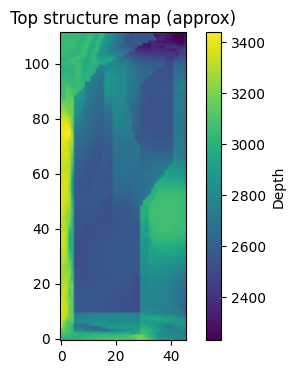

In [ ]:
# Top depth of each cell as min of its eight corners
top_z = zcorn_3d[0::2, 0::2, 0::2]  # one corner per cell pillar
top_map = top_z[0, :, :]            # top layer only

plt.figure(figsize=(5, 4))
plt.imshow(top_map, origin="lower")
plt.title("Top structure map (approx)")
plt.colorbar(label="Depth")
plt.show()

If you tell the actual nx, ny, nz, a more specific reshape and example (including XYZ export for e.g. PyVista) can be added.

### 4.2 Plotly Structure Map

In [ ]:
import plotly
import plotly.io as pio
pio.renderers.default = "colab"
import plotly.express as px

# Top depth of each cell as min of its eight corners
top_z = zcorn_3d[0::2, 0::2, 0::2]   # one corner per cell pillar
top_map = top_z[0, :, :]             # top layer only

# Option 1: simple imshow-style plot
fig = px.imshow(
    top_map,
    origin="lower",
    color_continuous_scale="Viridis",
    labels=dict(color="Depth")
)
fig.update_layout(
    title="Top Structure Map (approx)",
    xaxis_title="i",
    yaxis_title="j",
    height=600, width=400,
)

# Define title here to be accessible for saving
plot_title = "Top Structure Map"

# Ensure dest is a Path object for file operations
dest = Path(dest) # Explicitly convert dest to Path

plotly.offline.plot(fig, filename = str(dest / (plot_title + '.html'))) # Changed plotly.offline.plot to pyo.plot and title to plot_title
fig.write_image(str(dest / (plot_title + '.png')), scale=3.125) # Changed title to plot_title

fig.show()

Plotly’s built‑in continuous color scales are grouped into sequential, diverging, and cyclical families. Below is a compact list of the commonly used names that can be passed to color_continuous_scale in Plotly Express.

In [ ]:
import plotly.express as px

# Show all sequential names
dir(px.colors.sequential)

# Show all diverging names
dir(px.colors.diverging)

# Show all cyclical names
dir(px.colors.cyclical)

# View swatches of all continuous scales
px.colors.sequential.swatches_continuous().show()
px.colors.diverging.swatches_continuous().show()
px.colors.cyclical.swatches_continuous().show()

In [ ]:
# Option 2: more explicit Heatmap
import plotly
import plotly.io as pio
pio.renderers.default = "colab"
import plotly.graph_objects as go

fig = go.Figure(
    data=go.Heatmap(
        z=top_map,
        colorscale="Turbo_r",
        colorbar=dict(title="Depth")
    )
)

fig.update_yaxes(
    autorange="reversed",   # j increasing upward
    scaleanchor="x",        # lock pixel scale to x
    constrain="domain"      # compress domain instead of range
)
fig.update_xaxes(
    constrain="domain"      # needed for stable aspect
)

fig.update_layout(
    title="Top Structure Map",
    xaxis_title="i",
    yaxis_title="j",
    width=400,
    height=600            # square figure helps keep cells square
)

# Define title here to be accessible for saving
plot_title = "Top Structure Map"

# Ensure dest is a Path object for file operations
dest = Path(dest) # Explicitly convert dest to Path

plotly.offline.plot(fig, filename = str(dest / (plot_title + '.html'))) # Changed plotly.offline.plot to pyo.plot and title to plot_title
fig.write_image(str(dest / (plot_title + '.png')), scale=3.125)

fig.show()

## 5.0 3D Structure Map

In [ ]:
import plotly
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "colab"
import numpy as np

# Assume zcorn_3d already exists with shape (2*NZ, 2*NY, 2*NX)
# Top depth of each cell as min of its eight corners
top_z = zcorn_3d[0::2, 0::2, 0::2]   # one corner per cell pillar
top_map = top_z[0, :, :]             # top layer only  (NY, NX)

ny, nx = top_map.shape
x = np.arange(nx)
y = np.arange(ny)

fig = go.Figure(
    data=go.Surface(
        x=x,
        y=y,
        z=top_map,
        colorscale="Turbo_r",
        colorbar=dict(title="Depth")
    )
)

fig.update_layout(
    title="Top Structure Surface",
    scene=dict(
        xaxis_title="i",
        yaxis_title="j",
        zaxis_title="Depth",
        zaxis_autorange="reversed"  # depth increasing downwards
    ),
    width=800,
    height=600
)

# Define title here to be accessible for saving
plot_title = "Top Structure Surface"

# Ensure dest is a Path object for file operations
dest = Path(dest) # Explicitly convert dest to Path

plotly.offline.plot(fig, filename = str(dest / (plot_title + '.html')))
fig.write_image(str(dest / (plot_title + '.png')), scale=3.125)

fig.show()